<a href="https://colab.research.google.com/github/latika0128/Deep-Learning/blob/main/dl_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, GRU, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# STEP 1: LOAD DATA
df = pd.read_csv('tweets.csv')

# STEP 2: CLEANING
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['cleaned_text'] = df['text'].apply(clean_text)

# STEP 3: LABEL ENCODING
le = LabelEncoder()
y = le.fit_transform(df['airline_sentiment'])

# STEP 4: TOKENIZATION
max_features = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

X = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(X, maxlen=max_len)


In [ ]:

# STEP 5: TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 6: MODEL FUNCTION
def build_model(model_type='LSTM'):
    model = Sequential([
        Embedding(max_features, 128, input_length=max_len),
        SpatialDropout1D(0.2),
        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(pool_size=4),

        LSTM(64, dropout=0.2, recurrent_dropout=0.2)
        if model_type == 'LSTM'
        else GRU(64, dropout=0.2, recurrent_dropout=0.2),

        Dense(3, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [ ]:
# STEP 7: CALLBACK
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
# STEP 8: TRAIN CNN-LSTM
print("Training CNN-LSTM...")
cnn_lstm = build_model('LSTM')

start = time.time()
history_lstm = cnn_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
lstm_time = time.time() - start

Training CNN-LSTM...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


165/165 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.6739 - loss: 0.7587 - val_accuracy: 0.7534 - val_loss: 0.6352
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8043 - loss: 0.5009 - val_accuracy: 0.8166 - val_loss: 0.4965
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8713 - loss: 0.3430 - val_accuracy: 0.7944 - val_loss: 0.5352
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9109 - loss: 0.2413 - val_accuracy: 0.7918 - val_loss: 0.5727


In [ ]:
# STEP 9: TRAIN CNN-GRU
print("\nTraining CNN-GRU...")
cnn_gru = build_model('GRU')

start = time.time()
history_gru = cnn_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
gru_time = time.time() - start


Training CNN-GRU...
Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.6794 - loss: 0.7494 - val_accuracy: 0.7654 - val_loss: 0.5893
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8217 - loss: 0.4559 - val_accuracy: 0.8063 - val_loss: 0.5026


In [ ]:
# STEP 10: EVALUATION
def evaluate(model, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    return acc, y_pred

acc_lstm, y_pred_lstm = evaluate(cnn_lstm, "CNN-LSTM")
acc_gru, y_pred_gru = evaluate(cnn_gru, "CNN-GRU")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

CNN-LSTM Accuracy: 0.8040
              precision    recall  f1-score   support

    negative       0.87      0.90      0.88      1889
     neutral       0.65      0.55      0.59       580
    positive       0.71      0.73      0.72       459

    accuracy                           0.80      2928
   macro avg       0.74      0.73      0.73      2928
weighted avg       0.80      0.80      0.80      2928

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

CNN-GRU Accuracy: 0.7814
              precision    recall  f1-score   support

    negative       0.83      0.92      0.87      1889
     neutral       0.61      0.50      0.55       580
    positive       0.72      0.58      0.64       459

    accuracy                           0.78      2928
   macro avg       0.72      0.67      0.69      2928
weighted avg       0.77      0.78      0.77      2928



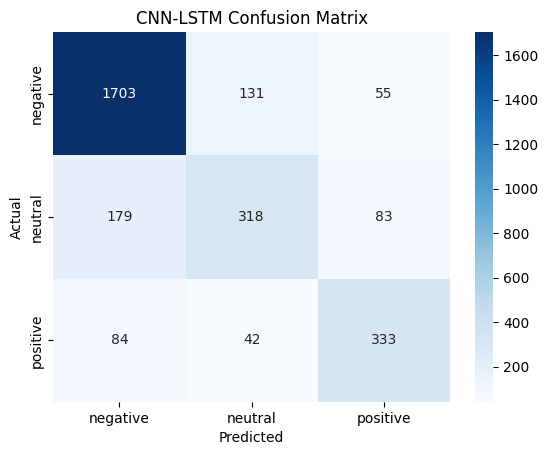

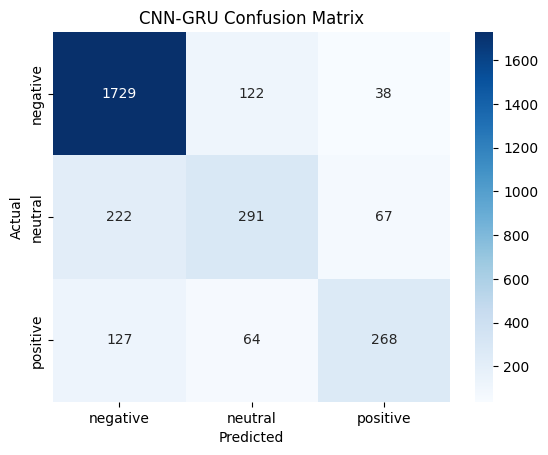

In [ ]:
# STEP 11: CONFUSION MATRIX
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_lstm, "CNN-LSTM Confusion Matrix")
plot_cm(y_test, y_pred_gru, "CNN-GRU Confusion Matrix")

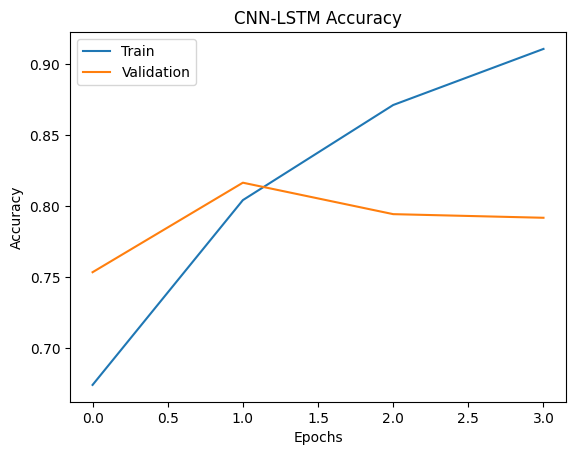

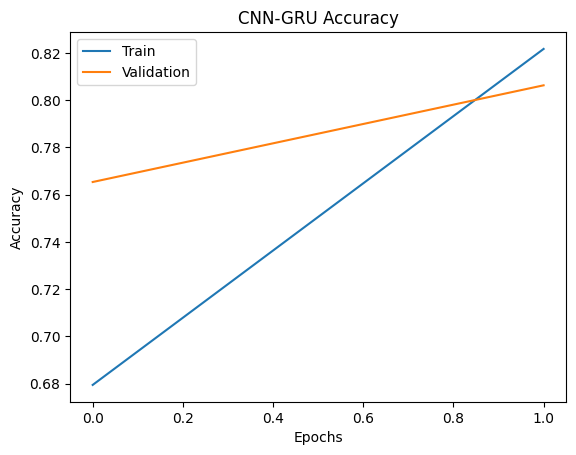

In [ ]:
# STEP 12: LEARNING CURVES
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_lstm, "CNN-LSTM Accuracy")
plot_history(history_gru, "CNN-GRU Accuracy")

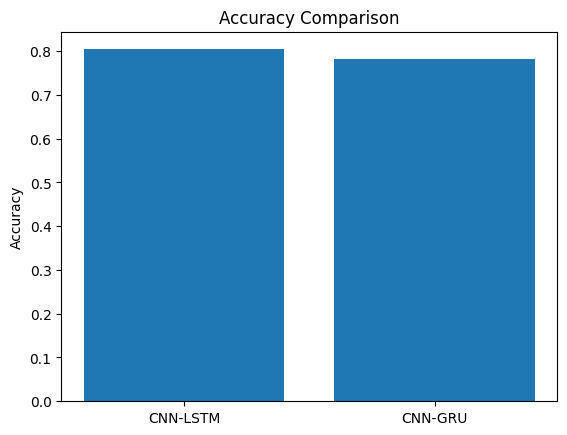

In [ ]:
# STEP 13: COMPARISON
plt.bar(['CNN-LSTM', 'CNN-GRU'], [acc_lstm, acc_gru])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# STEP 14: COMPLEXITY
def model_complexity(model, name):
    params = model.count_params()
    print(f"{name} Parameters: {params}")
    return params

params_lstm = model_complexity(cnn_lstm, "CNN-LSTM")
params_gru = model_complexity(cnn_gru, "CNN-GRU")

print("\nFINAL COMPARISON")
print(f"LSTM Accuracy: {acc_lstm:.4f}, Time: {lstm_time:.2f}s")
print(f"GRU Accuracy: {acc_gru:.4f}, Time: {gru_time:.2f}s")

CNN-LSTM Parameters: 1354243
CNN-GRU Parameters: 1346179

FINAL COMPARISON
LSTM Accuracy: 0.8040, Time: 38.71s
GRU Accuracy: 0.7814, Time: 21.63s
